# Drivers 01 — Waves (WHACS hindcast)
45 years (1979–2023) of hourly WHACS wave hindcast reduced to per-seapoint
climatology (`drivers/whacs.py`, streamed with numpy accumulators — ~6 min on
32 cores), then joined to transects: primarily via the line-of-sight-filtered
`Unique_ID → wave point` mapping from the Bruun-rule pipeline, nearest-seapoint
fallback elsewhere. Variables: mean/std/p50/p90/p99/max Hs, storm hours >4 m,
circular + energy-weighted mean direction, energy flux, period — each also
split into 1979–89 / 1990–2023 epochs for the epoch analysis.

In [1]:
import pandas as pd
from drivers import common
# the seapoint climatology is cached separately (rebuild takes ~6 min):
clim_path = common.DRIVER_DATA / "whacs_seapoint_climatology.parquet"
if not clim_path.exists():
    from drivers.whacs import build as build_clim
    build_clim()

In [2]:
import pandas as pd
from drivers import common

path = common.DRIVER_DATA / "d01_waves.parquet"
if not path.exists():
    from drivers.d01_waves import build
    df = build()
else:
    df = pd.read_parquet(path)
    print(f"loaded cached {path.name}: {len(df):,} rows")
df.head()

loaded cached d01_waves.parquet: 228,538 rows


,UniqueID,wave_join_method,wave_dist_m,hs_mean,hs_std,hs_p50,hs_p90,hs_p99,hs_max,storm_hrs_gt4m_yr,...,hs_p99_9023,hs_max_9023,storm_hrs_gt4m_yr_9023,dir_mean_9023,dir_energy_mean_9023,cge_mean_9023,t01_mean_9023,hs_mean_delta,hs_p99_delta,storm_hrs_delta
0,203054437032,nearest,8165.578213,2.559575,1.125004,2.3625,4.1375,5.7875,10.202,1018.504381,...,5.7625,10.202,1045.542096,261.283696,265.732749,41.64323,8.441478,0.104152,-0.025,110.600272
1,203054438164,nearest,8175.110861,2.559575,1.125004,2.3625,4.1375,5.7875,10.202,1018.504381,...,5.7625,10.202,1045.542096,261.283696,265.732749,41.64323,8.441478,0.104152,-0.025,110.600272
2,203054439252,nearest,8183.778850,2.559575,1.125004,2.3625,4.1375,5.7875,10.202,1018.504381,...,5.7625,10.202,1045.542096,261.283696,265.732749,41.64323,8.441478,0.104152,-0.025,110.600272
3,203054440300,nearest,8191.413157,2.559575,1.125004,2.3625,4.1375,5.7875,10.202,1018.504381,...,5.7625,10.202,1045.542096,261.283696,265.732749,41.64323,8.441478,0.104152,-0.025,110.600272
4,203054441325,nearest,8198.313617,2.559575,1.125004,2.3625,4.1375,5.7875,10.202,1018.504381,...,5.7625,10.202,1045.542096,261.283696,265.732749,41.64323,8.441478,0.104152,-0.025,110.600272


In [3]:
df.describe(include='all').T.head(40)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UniqueID,228538.0,NaN,NaN,NaN,139300979226.829895,48710893827.675819,100000185990.0,100422347904.25,100584280354.0,200240849080.75,203057476049.0
wave_join_method,228538,2,los_mapped,213093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wave_dist_m,228538.0,NaN,NaN,NaN,4710.863184,2039.658092,433.398759,3312.110293,4547.149988,5783.97175,17014.351971
hs_mean,228538.0,NaN,NaN,NaN,1.201288,0.46287,0.139335,0.89244,1.1694,1.518612,2.742052
hs_std,228538.0,NaN,NaN,NaN,0.579004,0.176792,0.133884,0.453143,0.600289,0.710138,1.13153
hs_p50,228538.0,NaN,NaN,NaN,1.071962,0.437506,0.0875,0.7875,1.0375,1.3875,2.5625
hs_p90,228538.0,NaN,NaN,NaN,1.986499,0.687817,0.3625,1.5125,1.9625,2.4625,4.3125
hs_p99,228538.0,NaN,NaN,NaN,3.072997,0.978529,0.5375,2.4625,3.1125,3.7375,5.9375
hs_max,228538.0,NaN,NaN,NaN,5.219232,1.778825,0.976,3.956,5.282,6.37,11.024
storm_hrs_gt4m_yr,228538.0,NaN,NaN,NaN,50.248625,102.59288,0.0,0.0,8.044567,48.022953,1196.218195


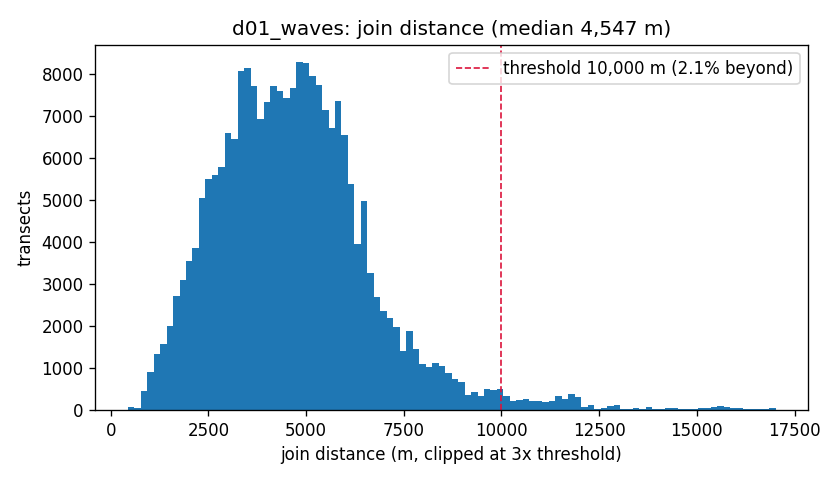

In [4]:
from IPython.display import Image, display
from drivers.common import QA_DIR
p = QA_DIR / 'd01_waves_join_dist.png'
display(Image(str(p), width=760)) if p.exists() else print('missing d01_waves_join_dist.png')